In [2]:
import torch

try:
    device = 'xpu' if torch.xpu.is_available() else 'cpu'
except ImportError:
    device = 'cpu'

device

'xpu'

In [5]:
import wandb # KEY: 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
from ultralytics import YOLOWorld


# 1. Initialize W&B project
wandb.init(project="phobia-detector-yoloworld", job_type="training")

# 2. Load the YOLO-World model
# Using 'v2' models is highly recommended for custom training
model = YOLOWorld('yolov8s-worldv2.pt')

# 3. Fine-tune
# The 'data' parameter points to the data.yaml file provided by Roboflow



model.train(
    data='insects-2/data.yaml',
    epochs=50,
    patience=5,
    imgsz=640,
    batch=16,
    device='cpu',      
    project="phobia-detector",
    name="insect_finetune",
    freeze=10,
    lr0=0.01,
    plots=True,
    mosaic=0.0,        # OFF: Don't combine 4 images into one (bad for small 224px imgs)
    mixup=0.0,         # OFF: Don't blend two images
    fliplr=0.5,        # ON: Random horizontal flip (insects look the same either way)
    flipud=0.0,        # OFF: Usually insects aren't seen upside down unless dead
    hsv_h=0.015,       # ON: Very slight color hue shift
    hsv_s=0.7,         # ON: Saturation shift
    hsv_v=0.4,         # ON: Brightness shift (helps with indoor/outdoor lighting)
    degrees=0.0,       # OFF: No rotation for this quick test
    scale=0.5,         # ON: Random zoom in/out to handle distance
    translate=0.1
)

# 4. Finish the W&B run
wandb.finish()

Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+xpu CPU (Intel Core Ultra 7 256V)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=insects-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-worldv2.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=insect_finetune2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspect

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



image 1/1 /home/aadit/FAI/final/Realtime-Phobia-Filter/insects-2/test/images/10_jpg.rf.85c6f87be5c13522e4852729f3ba0353.jpg: 640x640 (no detections), 227.6ms
Speed: 2.2ms preprocess, 227.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


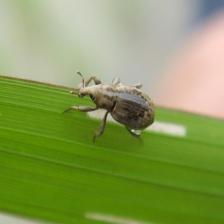

In [7]:
from ultralytics import YOLOWorld
model = YOLOWorld('runs/detect/phobia-detector/insect_finetune2/weights/best.pt')

results = model.predict("insects-2/test/images/10_jpg.rf.85c6f87be5c13522e4852729f3ba0353.jpg")
results[0].show()